# Evaluation exportierter Keras-Modelle

Dieses Notebook lädt bereits trainierte Modelle (`.keras`) und führt **nur Evaluation** aus:

- Vergleich der drei Modelle
- Confusion Matrix
- Classification Report
- Visualisierung von Beispielvorhersagen
- Fehleranalyse pro Klasse

Es wird **nicht** trainiert.

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from PIL import Image

print("TensorFlow-Version:", tf.__version__)
print("Keras-Version     :", tf.keras.__version__)

TensorFlow-Version: 2.21.0
Keras-Version     : 3.15.0


## 1) Pfade festlegen

In [2]:
DATA_DIR = Path("./data/garbage_classification_enhanced_500")
TEST_DIR = DATA_DIR / "test"

MODEL_MLP_PATH = Path("modell_01_mlp.keras")
MODEL_CNN_PATH = Path("modell_02_cnn.keras")
MODEL_TL_PATH  = Path("modell_03_efficientnetb0.keras")
CONFIG_PATH    = Path("model_config.json")

for p in [TEST_DIR, MODEL_MLP_PATH, MODEL_CNN_PATH, MODEL_TL_PATH, CONFIG_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Fehlt: {p}")

print("Alle benötigten Dateien gefunden.")

Alle benötigten Dateien gefunden.


## 2) Konfiguration laden

In [3]:
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = json.load(f)

num_classes       = int(cfg["num_classes"])
IMG_SIZE_SMALL    = tuple(cfg["img_size_small"])
IMG_SIZE_TRANSFER = tuple(cfg["img_size_transfer"])
class_names       = cfg["class_names"]

print("Geladene Konfiguration:")
print("  num_classes      :", num_classes)
print("  IMG_SIZE_SMALL   :", IMG_SIZE_SMALL)
print("  IMG_SIZE_TRANSFER:", IMG_SIZE_TRANSFER)
print("  class_names      :", class_names)

Geladene Konfiguration:
  num_classes      : 12
  IMG_SIZE_SMALL   : (128, 128)
  IMG_SIZE_TRANSFER: (224, 224)
  class_names      : ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


## 3) Test-Datensätze erstellen

In [4]:
BATCH_SIZE = 32

val_ds_small_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE_SMALL,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

val_ds_transfer_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE_TRANSFER,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
val_ds_small    = val_ds_small_raw.prefetch(buffer_size=AUTOTUNE)
val_ds_transfer = val_ds_transfer_raw.prefetch(buffer_size=AUTOTUNE)

print("Test-Datensätze erstellt.")

Found 1200 files belonging to 12 classes.
Found 1200 files belonging to 12 classes.
Test-Datensätze erstellt.


## 4) Modelle laden

In [5]:
mlp_model = tf.keras.models.load_model(MODEL_MLP_PATH)
cnn_model = tf.keras.models.load_model(MODEL_CNN_PATH)
tl_model  = tf.keras.models.load_model(MODEL_TL_PATH)

print("Modelle erfolgreich geladen:")
print(" ", MODEL_MLP_PATH.name)
print(" ", MODEL_CNN_PATH.name)
print(" ", MODEL_TL_PATH.name)

Modelle erfolgreich geladen:
  modell_01_mlp.keras
  modell_02_cnn.keras
  modell_03_efficientnetb0.keras


## 5) Evaluation aller drei Modelle

Modell                       Accuracy         Loss
1. MLP                        40.50 %       1.7452
2. Eigenes CNN                66.50 %       1.0500
3. EfficientNetB0             95.00 %       0.1526

Bestes Modell: 3. EfficientNetB0


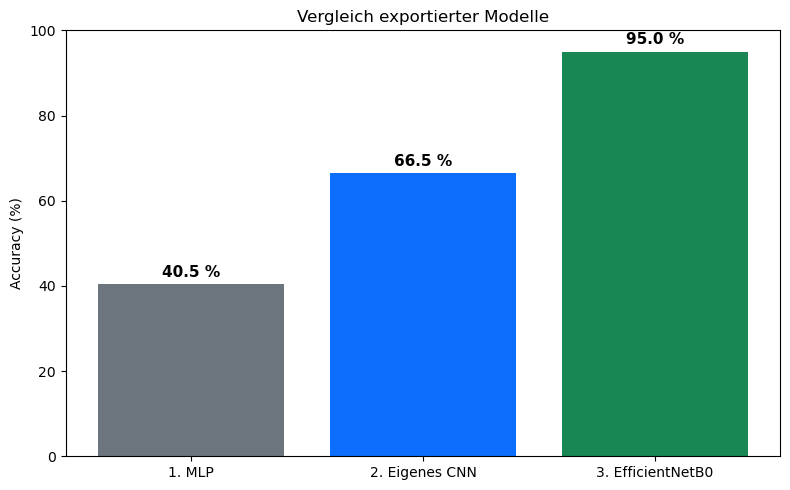

In [6]:
mlp_loss, mlp_acc = mlp_model.evaluate(val_ds_small, verbose=0)
cnn_loss, cnn_acc = cnn_model.evaluate(val_ds_small, verbose=0)
tl_loss,  tl_acc  = tl_model.evaluate(val_ds_transfer, verbose=0)

results = {
    "1. MLP":            {"acc": mlp_acc, "loss": mlp_loss},
    "2. Eigenes CNN":    {"acc": cnn_acc, "loss": cnn_loss},
    "3. EfficientNetB0": {"acc": tl_acc,  "loss": tl_loss},
}

print("=" * 60)
print(f"{'Modell':<24} {'Accuracy':>12} {'Loss':>12}")
print("=" * 60)
for name, vals in results.items():
    print(f"{name:<24} {vals['acc']*100:>10.2f} % {vals['loss']:>12.4f}")
print("=" * 60)

best_model_name = max(results, key=lambda k: results[k]["acc"])
print(f"\nBestes Modell: {best_model_name}")

plt.figure(figsize=(8, 5))
labels = list(results.keys())
accs = [results[k]["acc"] * 100 for k in labels]
farben = ["#6c757d", "#0d6efd", "#198754"]
bars = plt.bar(labels, accs, color=farben)
plt.ylabel("Accuracy (%)")
plt.title("Vergleich exportierter Modelle")
plt.ylim(0, 100)

for bar, val in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val:.1f} %", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

## 6) Confusion Matrix + Classification Report (bestes Modell)

Detailauswertung für: 3. EfficientNetB0
38/38 ━━━━━━━━━━━━━━━━━━━━ 26s 585ms/step


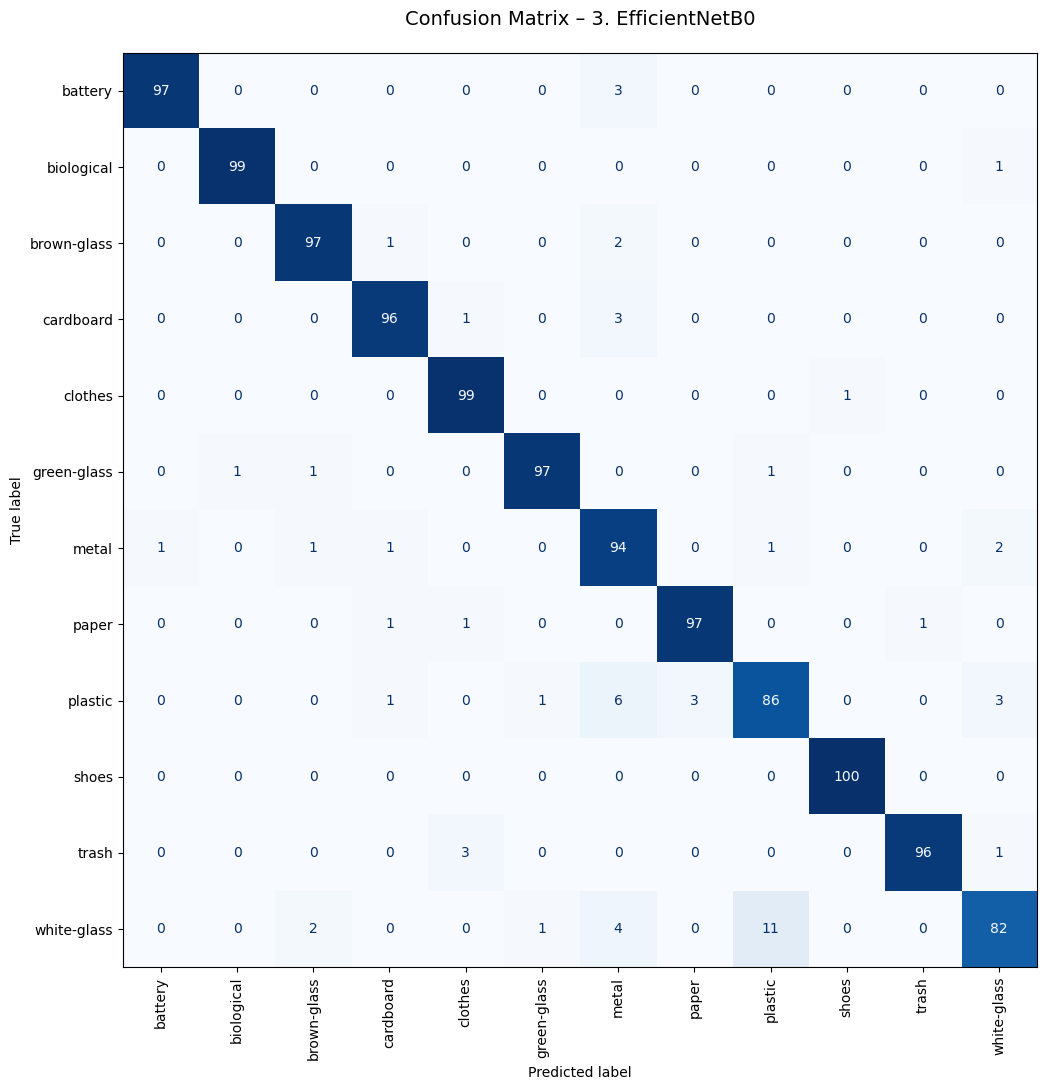


Classification Report:
              precision    recall  f1-score   support

     battery       0.99      0.97      0.98       100
  biological       0.99      0.99      0.99       100
 brown-glass       0.96      0.97      0.97       100
   cardboard       0.96      0.96      0.96       100
     clothes       0.95      0.99      0.97       100
 green-glass       0.98      0.97      0.97       100
       metal       0.84      0.94      0.89       100
       paper       0.97      0.97      0.97       100
     plastic       0.87      0.86      0.86       100
       shoes       0.99      1.00      1.00       100
       trash       0.99      0.96      0.97       100
 white-glass       0.92      0.82      0.87       100

    accuracy                           0.95      1200
   macro avg       0.95      0.95      0.95      1200
weighted avg       0.95      0.95      0.95      1200



In [7]:
model_map = {
    "1. MLP":            (mlp_model, val_ds_small),
    "2. Eigenes CNN":    (cnn_model, val_ds_small),
    "3. EfficientNetB0": (tl_model,  val_ds_transfer),
}

best_model, best_val_ds = model_map[best_model_name]
print(f"Detailauswertung für: {best_model_name}")

y_true = np.concatenate([y.numpy() for _, y in best_val_ds], axis=0)
y_pred_probs = best_model.predict(best_val_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(13, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation="vertical", ax=plt.gca(), colorbar=False)
plt.title(f"Confusion Matrix – {best_model_name}", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

## 7) Beispielvorhersagen visualisieren

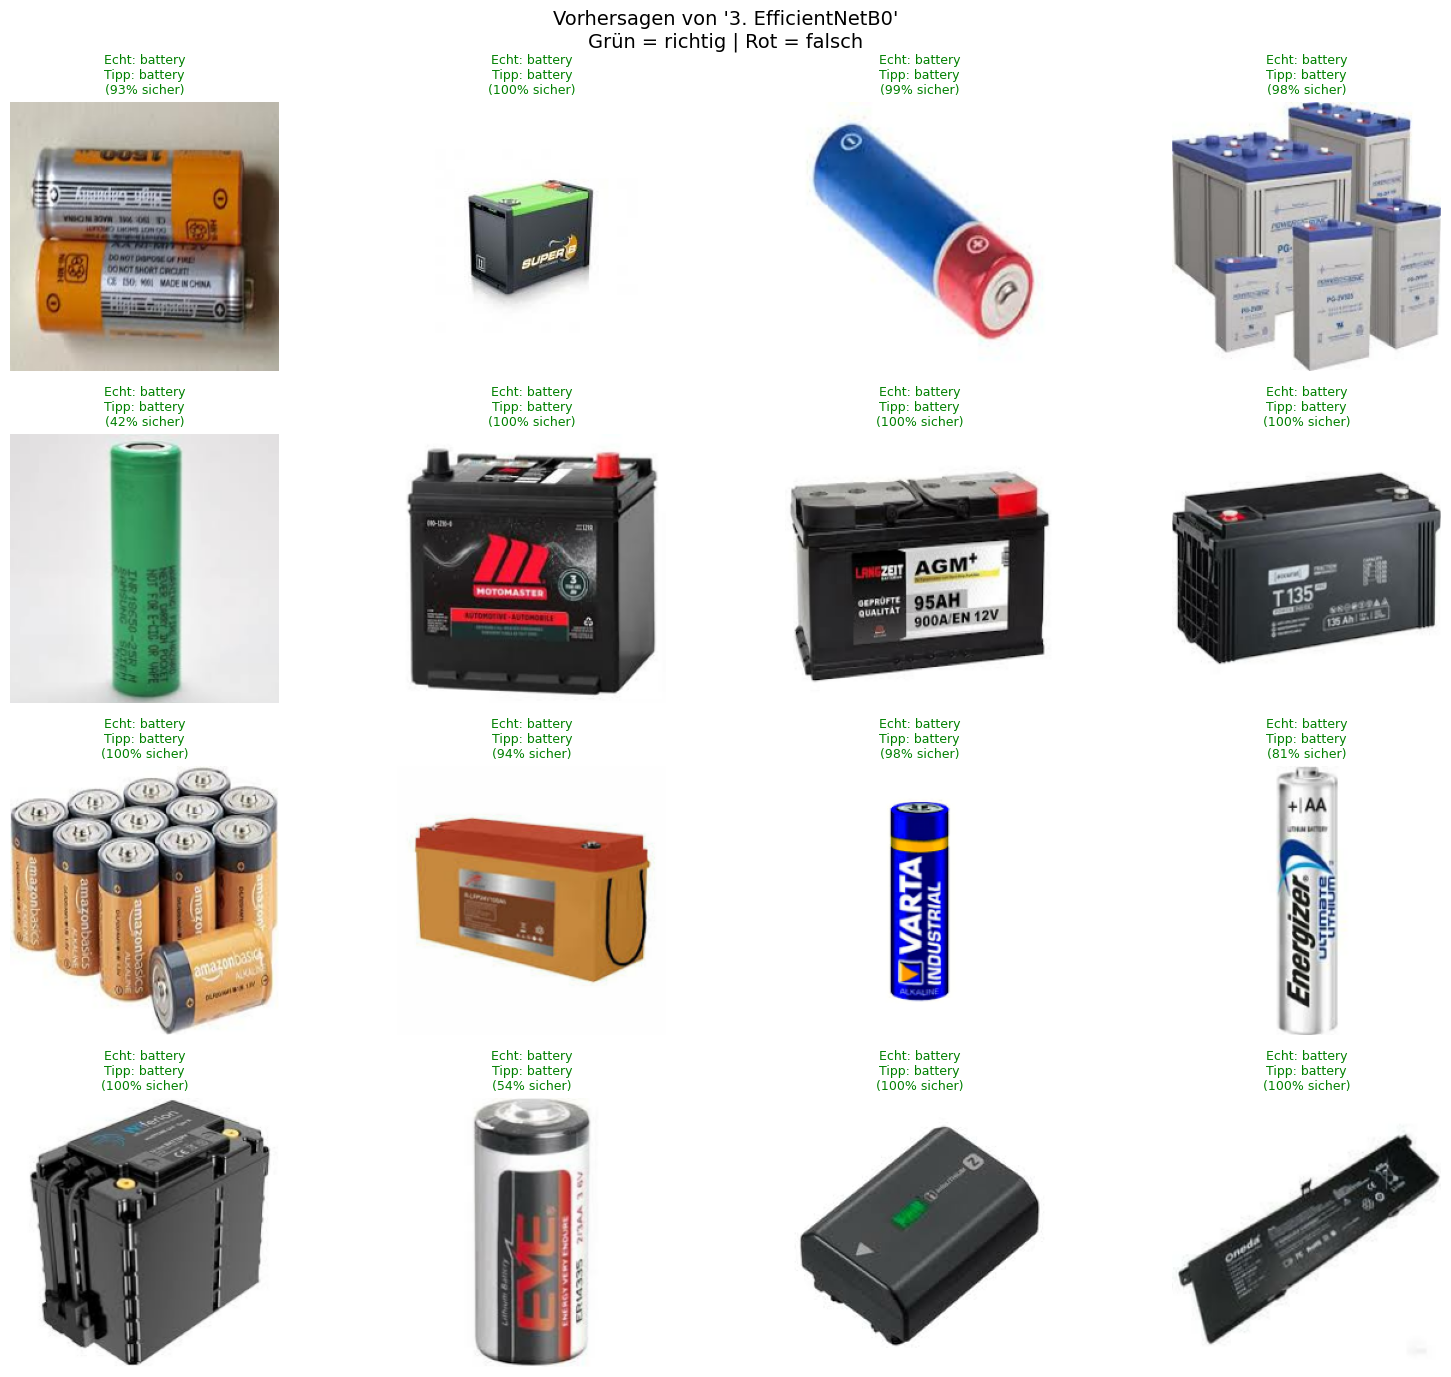

In [8]:
for images, labels in best_val_ds.take(1):
    batch_images = images.numpy()
    batch_labels = labels.numpy()

preds = best_model.predict(batch_images, verbose=0)
n_show = min(16, len(batch_images))

plt.figure(figsize=(16, 14))
plt.suptitle(f"Vorhersagen von '{best_model_name}'\nGrün = richtig | Rot = falsch", fontsize=14)

for i in range(n_show):
    plt.subplot(4, 4, i + 1)
    plt.imshow(batch_images[i].astype("uint8"))
    plt.axis("off")

    true_class = class_names[batch_labels[i]]
    pred_class = class_names[np.argmax(preds[i])]
    conf = np.max(preds[i]) * 100
    color = "green" if true_class == pred_class else "red"

    plt.title(f"Echt: {true_class}\nTipp: {pred_class}\n({conf:.0f}% sicher)", color=color, fontsize=9)

plt.tight_layout()
plt.show()

## 8) Fehleranalyse pro Klasse

Fehler gesamt: 60 von 1200 (5.0 %)


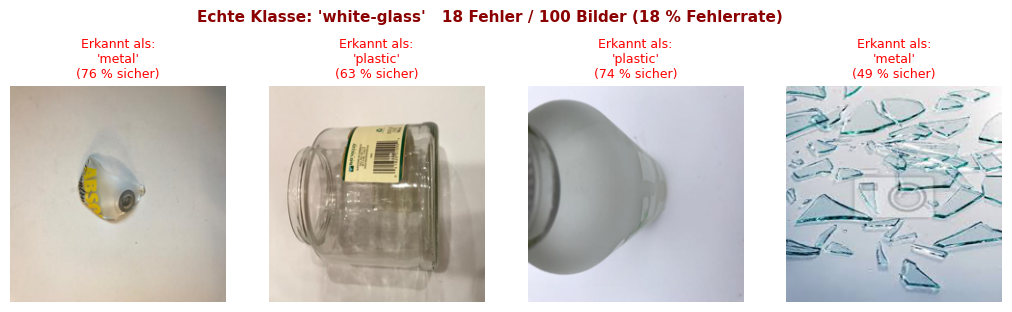

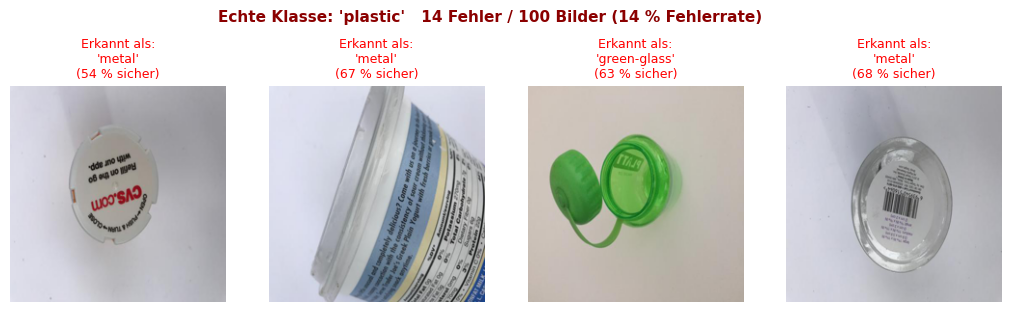

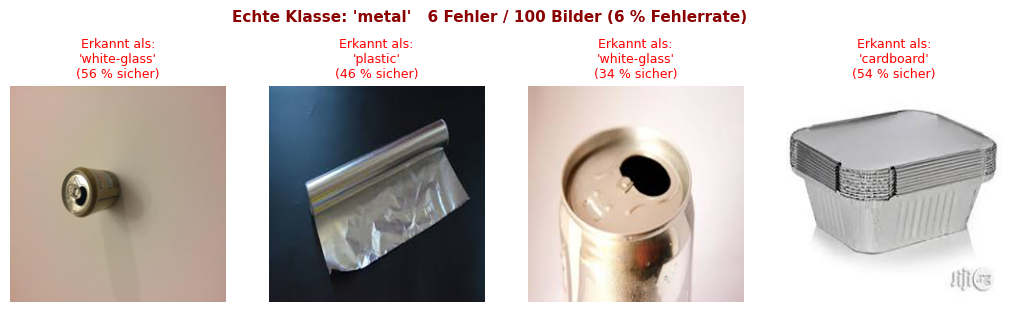

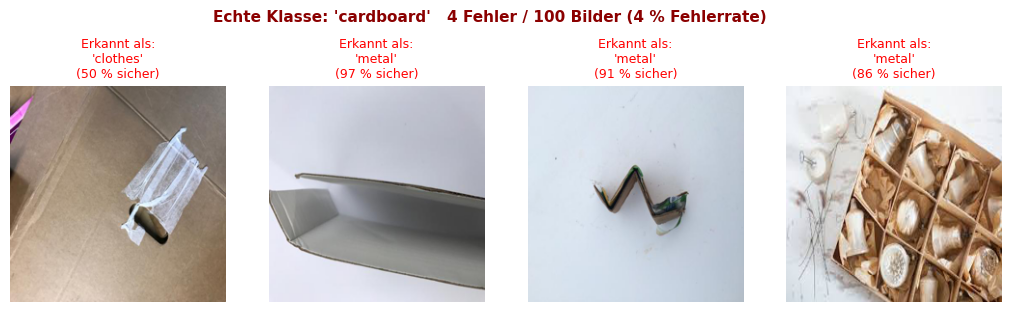

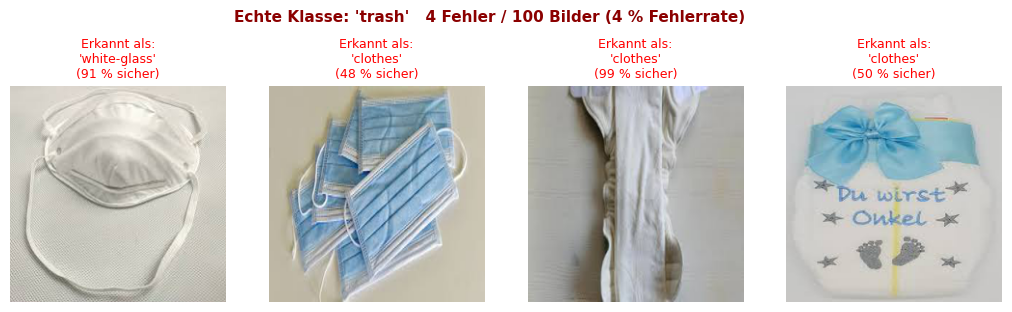

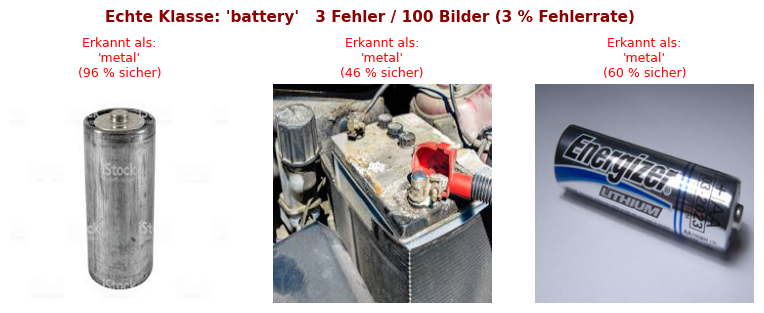

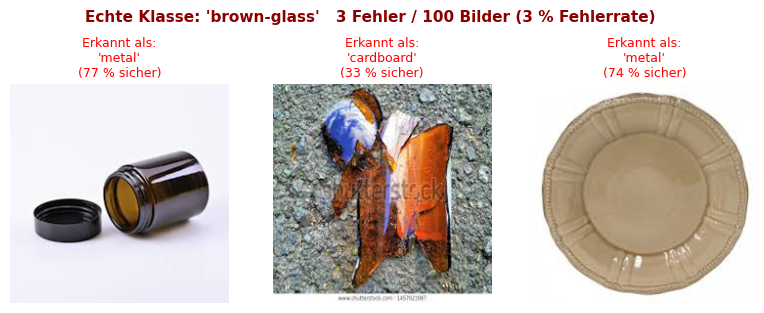

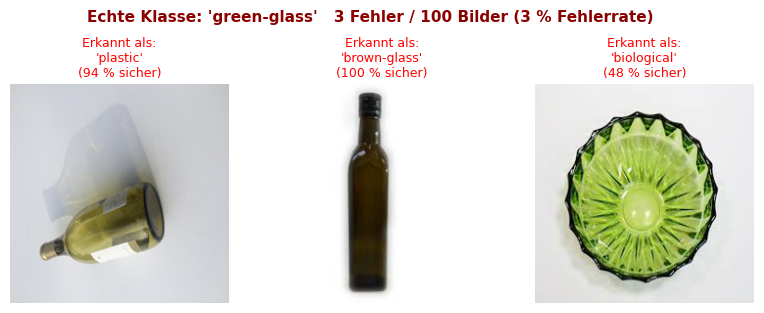

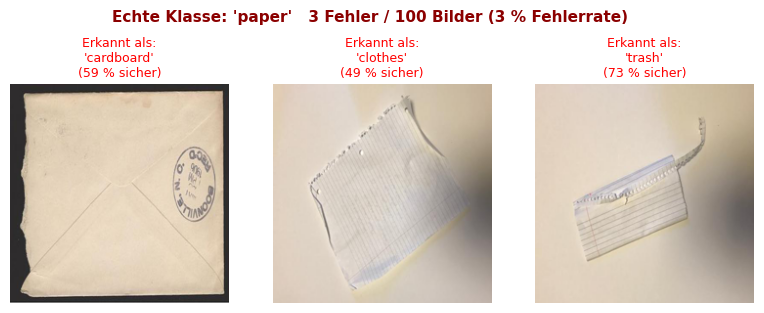

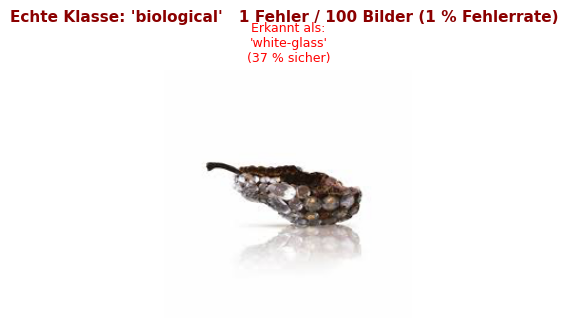

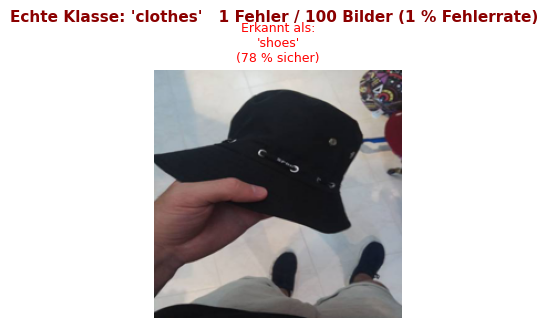

Evaluation abgeschlossen


In [10]:
MAX_PRO_KLASSE = 4

# Klassenverteilung im Testset
label_counts = np.zeros(num_classes, dtype=int)
for _, labels in val_ds_small_raw:
    for lbl in labels.numpy():
        label_counts[lbl] += 1

# Dateipfade in stabiler Reihenfolge aufbauen (wie y_true)
all_image_paths = []
for class_idx, class_name in enumerate(class_names):
    for p in sorted((TEST_DIR / class_name).glob("*.*")):
        all_image_paths.append((p, class_idx))

if len(all_image_paths) != len(y_pred):
    print("WARNUNG: Anzahl Dateipfade != Anzahl Predictions. Fehleranalyse übersprungen.")
else:
    errors_by_class = {name: [] for name in class_names}
    vis_size = IMG_SIZE_TRANSFER if best_model_name == "3. EfficientNetB0" else IMG_SIZE_SMALL

    for idx, (path, true_label) in enumerate(all_image_paths):
        if true_label != y_pred[idx]:
            img = np.array(Image.open(path).convert("RGB").resize(vis_size))
            pred_label_name = class_names[y_pred[idx]]
            confidence = float(np.max(y_pred_probs[idx])) * 100
            errors_by_class[class_names[true_label]].append((img, pred_label_name, confidence))

    classes_with_errors = sorted(
        [(name, errs) for name, errs in errors_by_class.items() if len(errs) > 0],
        key=lambda x: len(x[1]), reverse=True
    )

    total_errors = sum(len(errs) for _, errs in classes_with_errors)
    print(f"Fehler gesamt: {total_errors} von {len(all_image_paths)} ({total_errors / len(all_image_paths) * 100:.1f} %)")

    for cls_name, errs in classes_with_errors:
        n_show = min(MAX_PRO_KLASSE, len(errs))
        cls_idx = class_names.index(cls_name)
        n_total_cls = label_counts[cls_idx]
        err_rate = (len(errs) / n_total_cls * 100) if n_total_cls > 0 else 0.0

        fig, axes = plt.subplots(1, n_show, figsize=(n_show * 3.2, 3.8), squeeze=False)
        fig.suptitle(
            f"Echte Klasse: '{cls_name}'   {len(errs)} Fehler / {n_total_cls} Bilder ({err_rate:.0f} % Fehlerrate)",
            fontsize=11, fontweight="bold", color="darkred"
        )

        for ax, (img_array, pred_cls, conf) in zip(axes[0], errs[:n_show]):
            ax.imshow(img_array)
            ax.axis("off")
            ax.set_title(f"Erkannt als:\n'{pred_cls}'\n({conf:.0f} % sicher)", fontsize=9, color="red")

        plt.show()

print("Evaluation abgeschlossen")